# Tutorial 01 — Khám Phá Tín Hiệu Rung Ổ Lăn

## 🎯 Mục Tiêu
Hiểu **cách tín hiệu rung của ổ lăn bình thường vs lỗi khác nhau thế nào**. Trong tutorial này, bạn sẽ:
1. **Load tín hiệu thô** từ bộ dữ liệu CWRU
2. **Vẽ waveform** để thấy xung va chạm
3. **Phân tích phổ FFT & Envelope** để nhận biết "chữ ký" của từng loại lỗi

---

## 📌 Kỹ Năng Cần Có
- Numpy (xử lý mảng)
- Matplotlib (vẽ biểu đồ)
- Khái niệm cơ bản: **tần số lấy mẫu**, **FFT**, **Envelope**

In [ ]:
# Thêm đường dẫn dự án vào Python path
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
os.makedirs('../figures', exist_ok=True)

# Import thư viện chính
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import từ dự án
from src.config import FS, CLASS_NAMES, CLASS_COLORS, CLASS_DESC, BPFO, BPFI, BSF, FTF
from src.signal_utils import load_one_sample_per_class, envelope_spectrum

# Cấu hình matplotlib để biểu đồ đẹp
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style("whitegrid")

print("✅ Import thành công!")
print(f"   • Tần số lấy mẫu: {FS} Hz")
print(f"   • Các loại lỗi: {', '.join(CLASS_NAMES)}")

## 📊 Bước 1: Load Tín Hiệu Rung từ CWRU Dataset

### Bộ Dữ Liệu CWRU (Case Western Reserve University)

Đây là bộ dữ liệu **chuẩn benchmark quốc tế** cho chẩn đoán lỗi ổ lăn. Đặc điểm:

- **Cảm biến:** Gắn tại "Drive End" (DE) – gần ổ lăn nhất, nhạy nhất với lỗi
- **Tần số lấy mẫu:** 48 kHz (48,000 mẫu/giây)
- **Dữ liệu:** Mỗi file là một chuỗi tín hiệu liên tục (2-5 giây)
- **Định dạng:** .npy (NumPy binary format)

### 4 Trạng Thái Ổ Lăn

| Trạng thái | Ký hiệu | Mô tả | Cơ chế rung |
|---|---|---|---|
| **Bình thường** | Normal | Ổ lăn không lỗi | Rung nền đều, biên độ thấp |
| **Lỗi rãnh trong** | IR | Vết lỗi trên vòng trong quay | Xung lặp tại BPFI≈162Hz, bị điều chế theo RPM |
| **Lỗi rãnh ngoài** | OR | Vết lỗi trên vòng ngoài cố định | Xung lặp tại BPFO≈107Hz, rất đều → **dễ phát hiện** |
| **Lỗi bi** | B | Vết lỗi trên bề mặt viên bi | Xung lặp tại BSF≈141Hz, phức tạp → **khó phát hiện** |

In [ ]:
# Load một tín hiệu đại diện cho mỗi loại lỗi từ dataset 0HP (không tải)
print("🔄 Đang load tín hiệu từ CWRU Dataset (0HP - không tải)...\n")
samples = load_one_sample_per_class(domain='0HP')

# In ra thông tin chi tiết về mỗi tín hiệu
print("📌 Kích thước dữ liệu:")
print("-" * 60)
for label in CLASS_NAMES:
    if label in samples:
        sig = samples[label]
        n_samples = len(sig)
        duration = n_samples / FS  # Tính độ dài tín hiệu (giây)
        print(f"  {label:10s}: {n_samples:>10,} mẫu = {duration:>6.2f} giây")
print("-" * 60)

## 📈 Bước 2: Vẽ Waveform — "Nhìn" Tín Hiệu Thô

### Waveform Là Gì?

**Waveform** = biểu đồ giá trị tín hiệu theo thời gian (trục X = thời gian, trục Y = gia tốc). 

Bằng cách nhìn waveform, kỹ sư có thể:
- Thấy **xung va chạm** (xung nhọn, tập trung): dấu hiệu lỗi
- Thấy **tần suất xung**: dự đoán loại lỗi (BPFO? BPFI? BSF?)
- So sánh với lỗi bình thường (rung nền, không xung rõ)

### Zoom 50 ms Để Thấy Chi Tiết

Tín hiệu quá dài (2-5 giây), nên ta **zoom vào 50 ms đầu tiên** (2,400 mẫu ở 48kHz) để thấy rõ hình dạng xung.

**Lý do chọn 50 ms?**
- Ở tốc độ ~1800 RPM: một vòng quay ≈ 33 ms
- 50 ms ≈ 1.5 vòng quay → đủ để thấy mẫu lặp lại

In [ ]:
# Vẽ 4 biểu đồ (một cho mỗi loại lỗi), share cùng trục X để so sánh dễ
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('🔍 Waveform Tín Hiệu Rung — Zoom 50 ms (Chi Tiết)', 
             fontsize=14, fontweight='bold')

# Tính số mẫu cho 50 ms
zoom_ms = 50
zoom_n = int(zoom_ms / 1000 * FS)  # 50 ms = 2400 mẫu ở 48kHz

# Vẽ từng loại lỗi
for ax, cls in zip(axes, CLASS_NAMES):
    if cls not in samples:
        continue
    
    sig = samples[cls]
    
    # Tính trục thời gian (đơn vị: ms)
    t = np.arange(zoom_n) / FS * 1000
    
    # Lấy màu từ config
    color = CLASS_COLORS[cls]
    desc = CLASS_DESC[cls]
    
    # Vẽ đường
    ax.plot(t, sig[:zoom_n], lw=0.8, color=color, alpha=0.8)
    
    # Tuỳ chỉnh trục Y: hiển thị tên lỗi
    ax.set_ylabel(f'{cls}\n({desc})', 
                  fontsize=10, color=color, fontweight='bold')
    ax.set_ylim([sig[:zoom_n].min() - 1, sig[:zoom_n].max() + 1])
    ax.grid(True, alpha=0.3)

# Tuỳ chỉnh trục X
axes[-1].set_xlabel('Thời gian (ms)', fontsize=11)
axes[-1].set_xlim(0, zoom_ms)

plt.tight_layout()
plt.savefig('../figures/waveform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Hình waveform đã lưu vào: figures/waveform_comparison.png")

### 🔎 Cách Đọc Waveform Như Kỹ Sư

#### **1. Normal (Bình thường)**
- Dạng sóng **đều đặn**, biên độ **nhỏ** (±1 g)
- **Không có xung** rõ rệt → rung nền bình thường
- **Kết luận:** Ổ lăn lành mạnh, không có lỗi

#### **2. OR — Outer Race (Lỗi Rãnh Ngoài)**
- Thấy **xung lặp cách đều** ~ 9.3 ms (= 1/107Hz)
  - **Vì sao?** Mỗi giây có 107 lần bi đi qua vết lỗi rãnh ngoài (BPFO=107Hz)
  - Vết lỗi **cố định** ở vòng ngoài → mọi bi đều "kích" lỗi với cường độ **tương tự** → xung rất **đều đặn**
- **Biên độ xung:** ~2-3 g (cao hơn Normal nhưng không quá)
- **Kết luận:** Dễ phát hiện nhất vì xung rõ và đều

#### **3. IR — Inner Race (Lỗi Rãnh Trong)**
- Thấy **xung lặp nhưng biên độ thay đổi** (lúc cao lúc thấp)
  - **Vì sao?** Vết lỗi trên vòng trong quay cùng trục
  - Lúc vết lỗi ở "6 giờ" (vùng chịu tải) → bi va chạm mạnh → xung cao
  - Lúc vết lỗi ở "12 giờ" (ngoài vùng tải) → bi va chạm yếu → xung thấp
  - Kết quả: xung bị **"điều chế"** (modulation)
- **Biên độ xung:** 3-4 g (cao hơn OR)
- **Kết luận:** Khó hơn Normal nhưng vẫn nhận biết được do điều chế rõ

#### **4. B — Ball Fault (Lỗi Bi)**
- Thấy **xung phức tạp hơn**, không lặp đều
  - **Vì sao?** Bi vừa tịnh tiến trong ổ vừa tự quay quanh trục
  - Vết lỗi trên bi khi tiếp xúc rãnh trong → va chạm, khi tiếp xúc rãnh ngoài → lại va chạm
  - Vòng thêm bi tự quay → tín hiệu trở nên phức tạp
- **Biên độ xung:** ~1-2 g (thấp nhất!)
- **Kết luận:** Khó phát hiện nhất vì xung nhỏ và không đều

---

### 📝 Tóm Tắt Waveform

| Loại lỗi | Hình dạng | Biên độ | Tính chất | Độ khó phát hiện |
|---|---|---|---|---|
| **Normal** | Đều, không xung | Rất thấp (<1g) | Rung nền | ⭐ Dễ |
| **OR** | Xung lặp đều | Vừa (2-3g) | Rõ ràng, đều | ⭐ Dễ |
| **IR** | Xung không đều (bị điều chế) | Cao (3-4g) | Có mẫu lặp | ⭐⭐ Trung bình |
| **B** | Xung phức tạp, ngẫu nhiên | Thấp (1-2g) | Khó nhận biết | ⭐⭐⭐ Khó |

## 🎯 Bước 3: "Chữ Ký" Rung — 3 Góc Nhìn (Waveform + FFT + Envelope)

### Tại Sao Cần 3 Góc Nhìn?

**Waveform thôi không đủ!** Vì sao?
- Tín hiệu rung rất phức tạp, có nhiều thành phần tần số trộn lẫn
- Xung nhỏ (Ball fault) có thể bị "chôn" trong rung nền
- Cần phân tích **miền tần số** để "bộc lộ" tần số lỗi ẩn

### 3 Phương Pháp Phân Tích

1. **Waveform (Miền Thời Gian)** 
   - Nhìn xung trực tiếp
   - Tốt cho phát hiện nhanh lỗi lớn (OR)
   - Không tốt cho lỗi nhỏ (Ball)

2. **FFT Phổ (Fast Fourier Transform)**
   - "Mở rộng" tín hiệu thành các thành phần tần số
   - Thấy **tần số nào mạnh**: BPFO? BPFI? BSF?
   - Vấn đề: xung nhỏ có thể bị yếu trong phổ

3. **Envelope Spectrum (Phổ Đường Bao)**
   - Bước 1: Bandpass filter ở dải tần cao (2-5 kHz) → "vùng cộng hưởng"
   - Bước 2: Lấy đường bao (envelope) → "giải điều chế" xung
   - Bước 3: FFT envelope → thấy tần số xung rõ ràng!
   - **Lợi ích:** Xung nhỏ (Ball) cũng phát hiện được

---

### 🎨 Biểu Đồ 4×3

Ta sẽ vẽ một hình có:
- **4 hàng** (4 loại lỗi)
- **3 cột** (Waveform, FFT, Envelope)

Bằng cách này, ta có thể **so sánh từng loại lỗi qua 3 góc nhìn** cùng lúc.

In [ ]:
# Vẽ biểu đồ 4 hàng (loại lỗi) × 3 cột (waveform, FFT, envelope spectrum)
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('⭐ Chữ Ký Rung Của 4 Loại Lỗi Ổ Lăn\n' + 
             '(Waveform • FFT • Envelope Spectrum)',
             fontsize=14, fontweight='bold', y=1.00)

zoom_n = int(0.05 * FS)  # 50 ms để vẽ zoom waveform

# ===== VÒNG LẶP CHÍNH =====
for row, cls in enumerate(CLASS_NAMES):
    if cls not in samples:
        continue
    
    sig = samples[cls]
    color = CLASS_COLORS[cls]
    
    # ===== CỘT 1: WAVEFORM (ZOOM 50MS) =====
    t = np.arange(zoom_n) / FS * 1000  # Convert to ms
    axes[row, 0].plot(t, sig[:zoom_n], lw=0.6, color=color)
    axes[row, 0].set_ylabel(CLASS_DESC[cls], fontsize=10, 
                            color=color, fontweight='bold')
    if row == 0:
        axes[row, 0].set_title('Waveform\n(zoom 50ms)', fontsize=11, fontweight='bold')
    if row == 3:
        axes[row, 0].set_xlabel('Thời gian (ms)', fontsize=10)
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].set_xlim(0, 50)
    
    # ===== CỘT 2: FFT PHỔ (0-600 Hz) =====
    n_fft = min(len(sig), FS * 2)  # Dùng 2 giây để tính FFT
    chunk = sig[:n_fft]
    freqs = np.fft.fftfreq(n_fft, 1/FS)[:n_fft//2]
    fft_mag = np.abs(np.fft.fft(chunk)[:n_fft//2]) * 2 / n_fft
    
    # Lọc chỉ lấy 0-600 Hz
    mask_fft = freqs <= 600
    axes[row, 1].plot(freqs[mask_fft], fft_mag[mask_fft], 
                      lw=0.8, color=color, alpha=0.8)
    
    # Vẽ các đường dọc ở BPFO, BPFI, BSF (để dễ nhận biết)
    axes[row, 1].axvline(BPFO, ls='--', lw=1.2, color='red', alpha=0.6, label='BPFO' if row == 0 else '')
    axes[row, 1].axvline(BPFI, ls='--', lw=1.2, color='blue', alpha=0.6, label='BPFI' if row == 0 else '')
    axes[row, 1].axvline(BSF, ls='--', lw=1.2, color='green', alpha=0.6, label='BSF' if row == 0 else '')
    
    if row == 0:
        axes[row, 1].set_title('FFT Phổ\n(0-600 Hz)', fontsize=11, fontweight='bold')
        axes[row, 1].legend(fontsize=8, loc='upper right')
    if row == 3:
        axes[row, 1].set_xlabel('Tần số (Hz)', fontsize=10)
    axes[row, 1].grid(True, alpha=0.3)
    
    # ===== CỘT 3: ENVELOPE SPECTRUM (0-500 Hz) =====
    chunk_env = sig[:min(len(sig), FS * 2)]
    freqs_env, env_fft, _, _ = envelope_spectrum(chunk_env, FS)
    
    # Lọc chỉ lấy 0-500 Hz
    mask_env = freqs_env <= 500
    axes[row, 2].plot(freqs_env[mask_env], env_fft[mask_env], 
                      lw=1, color=color, alpha=0.8)
    
    # Vẽ các đường dọc ở BPFO, BPFI, BSF
    axes[row, 2].axvline(BPFO, ls='--', lw=1.2, color='red', alpha=0.6)
    axes[row, 2].axvline(BPFI, ls='--', lw=1.2, color='blue', alpha=0.6)
    axes[row, 2].axvline(BSF, ls='--', lw=1.2, color='green', alpha=0.6)
    
    if row == 0:
        axes[row, 2].set_title('Envelope Spectrum\n(0-500 Hz)', fontsize=11, fontweight='bold')
    if row == 3:
        axes[row, 2].set_xlabel('Tần số (Hz)', fontsize=10)
    axes[row, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fault_signatures_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Hình chữ ký rung đã lưu vào: figures/fault_signatures_detailed.png")

### 🔍 Cách Đọc "Chữ Ký" Từng Loại Lỗi

#### **Normal (Bình Thường)**

| Cột | Quan Sát |
|---|---|
| **Waveform** | Sóng đều, biên độ nhỏ (<1g), không xung nhọn |
| **FFT** | Phẳng, không đỉnh nổi bật → tín hiệu là rung nền |
| **Envelope** | Gần như bằng 0 → không có xung va chạm |
| **Kết luận** | ✅ Ổ lăn lành mạnh, không có lỗi |

---

#### **OR — Outer Race (Lỗi Rãnh Ngoài) ⭐ DỄ PHÁT HIỆN NHẤT**

| Cột | Quan Sát |
|---|---|
| **Waveform** | Xung lặp **cách đều ~9.3 ms**, biên độ 2-3g |
| **FFT** | Đỉnh **rõ tại 107 Hz (BPFO)** và các bội số (214, 321 Hz, ...) |
| **Envelope** | **Đỉnh rất cao tại 107 Hz** → tín hiệu envelope "bắt được" xung va chạm |
| **Lý do rõ** | Vết lỗi cố định trên vòng ngoài → mọi bi đều "kích" lỗi → xung rất đều |
| **Kết luận** | 🔴 Lỗi rãnh ngoài, dễ phát hiện sớm |

---

#### **IR — Inner Race (Lỗi Rãnh Trong) ⭐⭐ TRUNG BÌNH**

| Cột | Quan Sát |
|---|---|
| **Waveform** | Xung lặp nhưng **biên độ thay đổi** (lúc cao, lúc thấp) — bị "điều chế" |
| **FFT** | Đỉnh tại **162 Hz (BPFI)** + nhiều **sidebands quanh 162 Hz** (162±30, 162±60, ...) |
| **Envelope** | Đỉnh **cao tại 162 Hz** + sidebands → điều chế rõ ràng |
| **Lý do điều chế** | Vết lỗi quay cùng trục; khi ở vùng tải xung mạnh, khi ra ngoài xung yếu |
| **Kết luận** | 🟠 Lỗi rãnh trong, cần theo dõi cẩn thận (diễn tiến nhanh) |

---

#### **B — Ball Fault (Lỗi Bi) ⭐⭐⭐ KHÓ PHÁT HIỆN NHẤT**

| Cột | Quan Sát |
|---|---|
| **Waveform** | Xung **phức tạp, không đều**, biên độ **thấp nhất (1-2g)** |
| **FFT** | Đỉnh **141 Hz (BSF) nhưng biên độ thấp** → dễ nhầm với noise |
| **Envelope** | Đỉnh tại **141 Hz khá rõ** → envelope giúp "bộc lộ" xung nhỏ |
| **Lý do khó** | Bi vừa tịnh tiến vừa tự quay → xung không đều, năng lượng phân tán |
| **Kết luận** | ⚠️ Lỗi bi, cần chú ý envelope spectrum để phát hiện sớm |

---

### 📋 Bảng So Sánh "Chữ Ký"

| Loại Lỗi | Waveform | FFT Phổ | Envelope | Dễ Phát Hiện |
|---|---|---|---|---|
| **Normal** | Đều, không xung | Phẳng | Bằng 0 | ⭐ Dễ |
| **OR** | Xung lặp đều | Đỉnh rõ tại BPFO | Đỉnh cao tại BPFO | ⭐ Dễ |
| **IR** | Xung không đều (bị điều chế) | Đỉnh BPFI + sidebands | Đỉnh BPFI + sidebands | ⭐⭐ Trung bình |
| **B** | Xung phức tạp, nhỏ | Đỉnh BPFO thấp | Đỉnh BPFO rõ nhất | ⭐⭐⭐ Khó |

---

## 🎓 Tóm Tắt Tutorial 01

✅ **Bạn đã học được:**
1. Tín hiệu rung của **4 trạng thái ổ lăn** khác nhau
2. Cách **đọc waveform** để nhận biết xung va chạm
3. Cách dùng **FFT phổ** để nhìn thấy tần số lỗi
4. Cách dùng **envelope spectrum** để phát hiện lỗi nhỏ (Ball)
5. "**Chữ ký**" (signature) của từng loại lỗi là gì

✨ **Bước tiếp theo:** Tutorial 02 — Đi sâu vào **FFT & Phổ Tần Số**

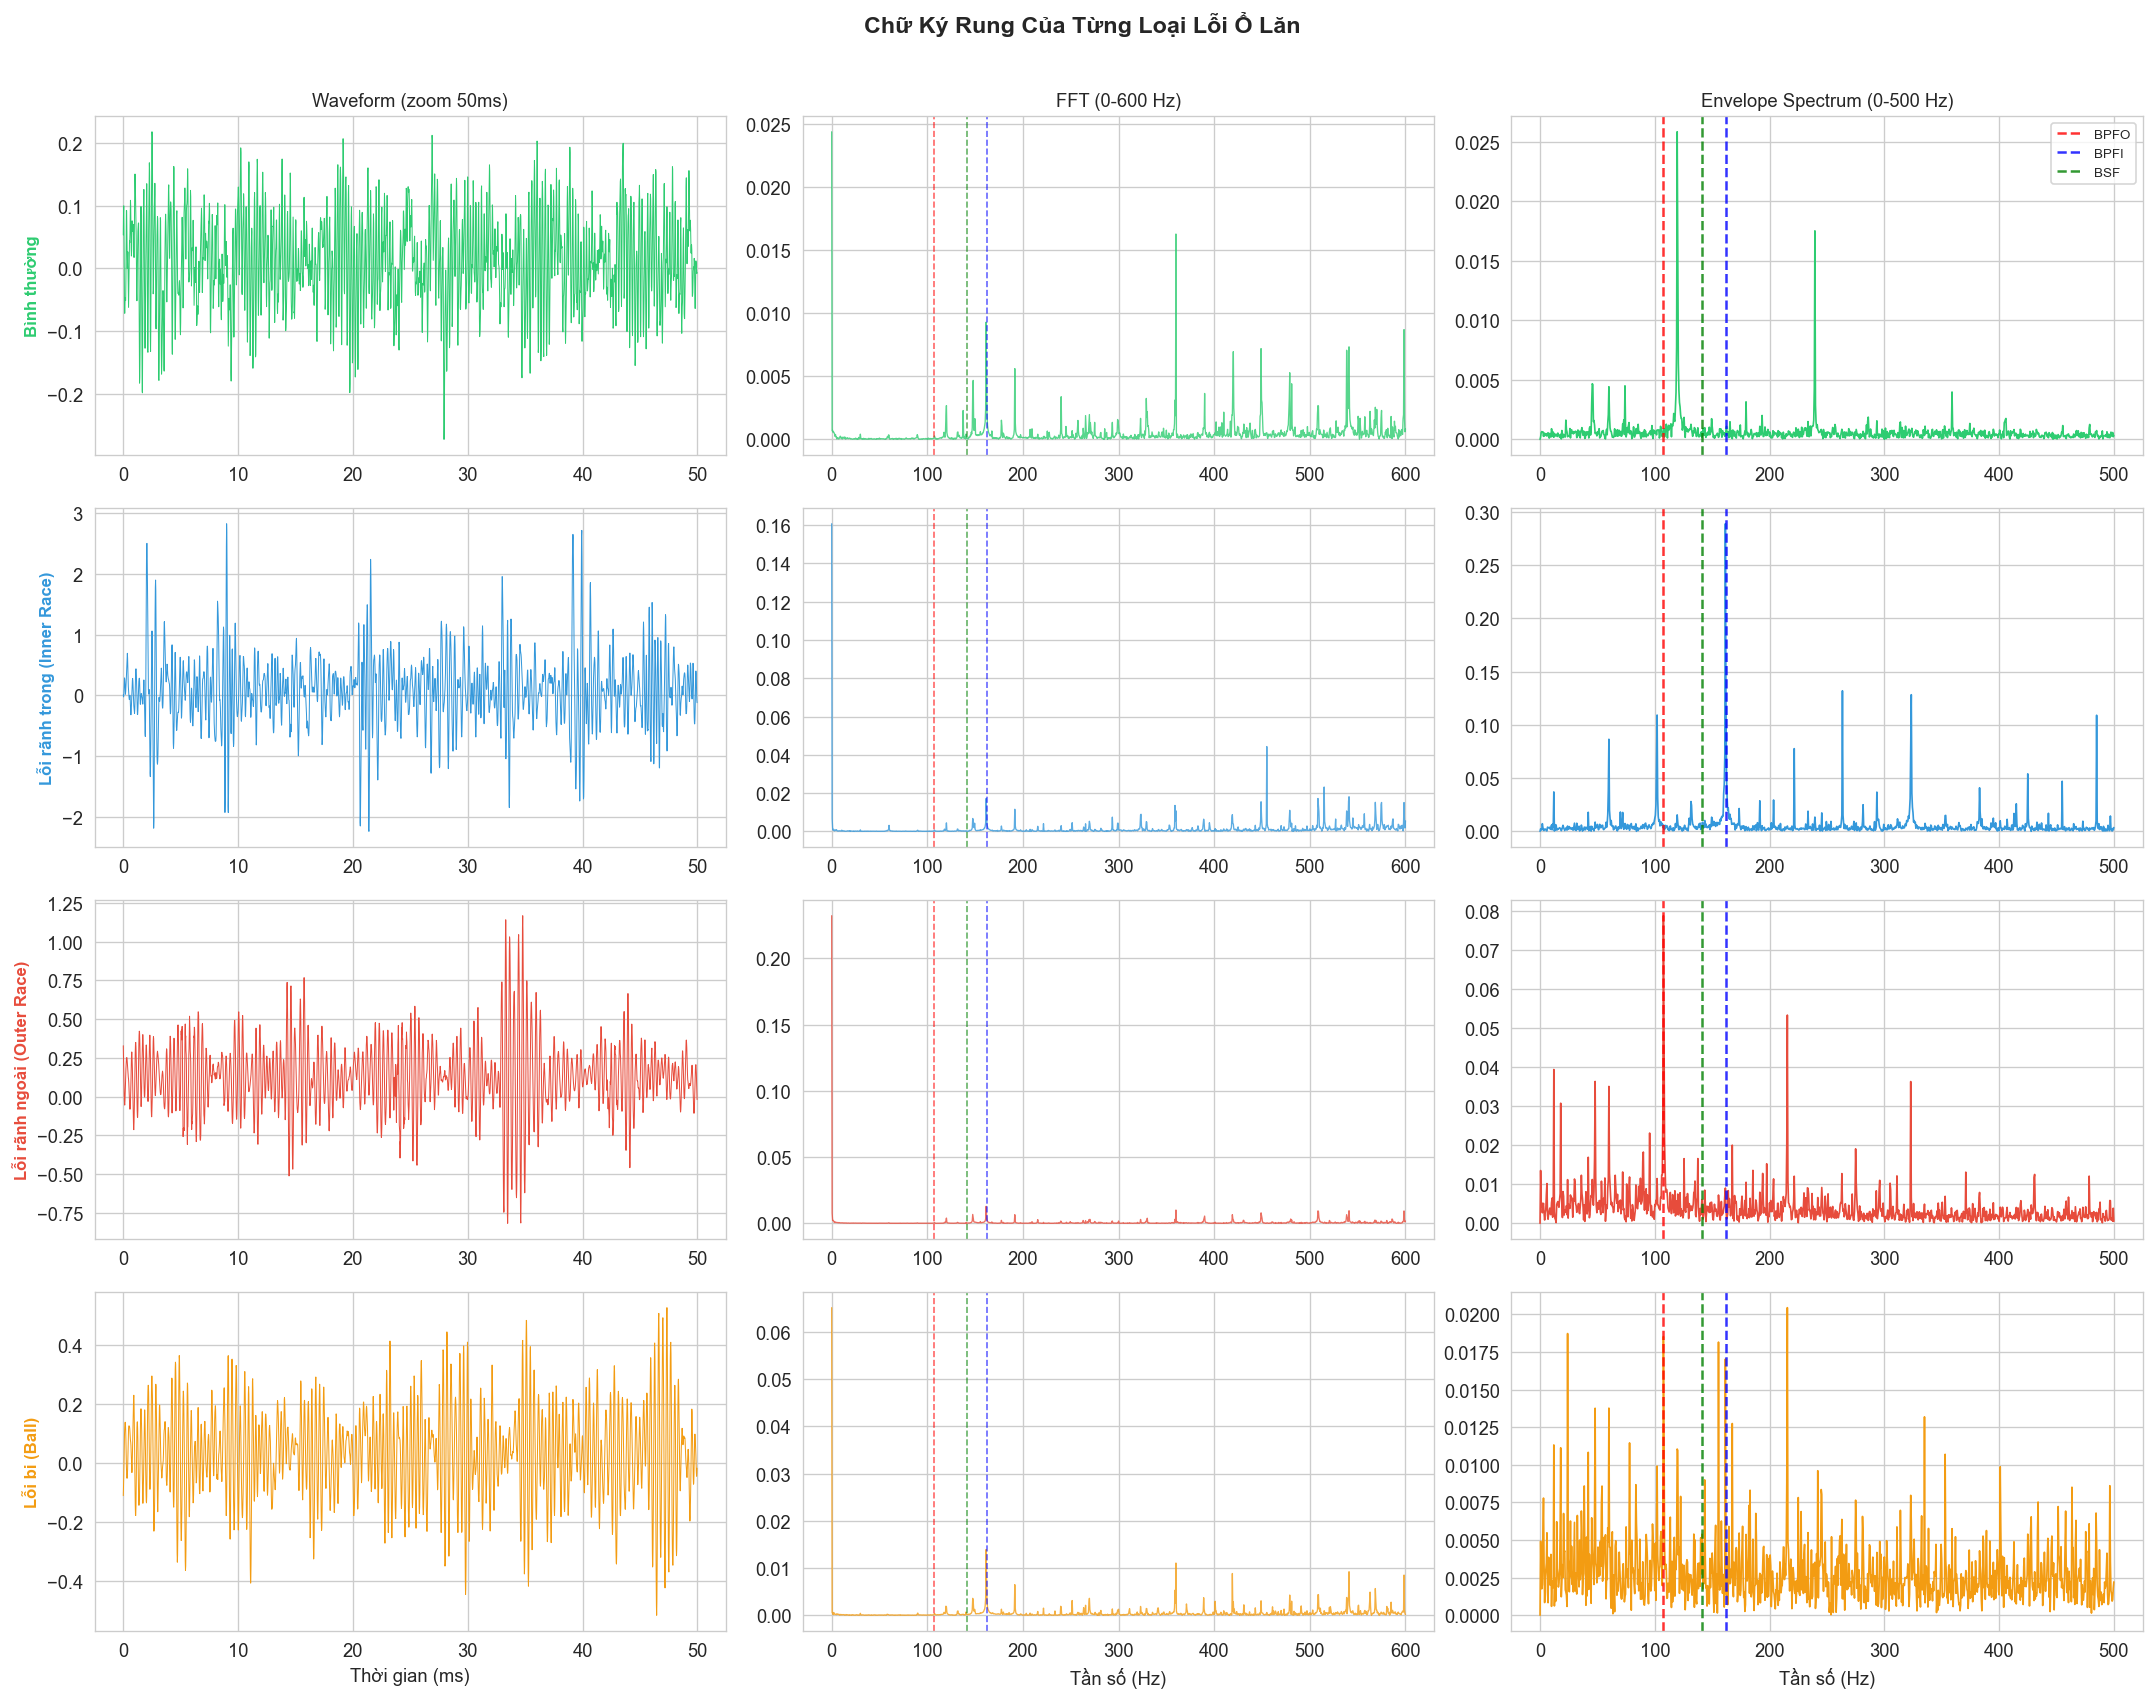

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Chữ Ký Rung Của Từng Loại Lỗi Ổ Lăn', fontsize=14, fontweight='bold', y=1.01)

zoom_n = int(0.05 * FS)

for row, cls in enumerate(CLASS_NAMES):
    if cls not in samples: continue
    sig = samples[cls]
    color = CLASS_COLORS[cls]

    # Cột 1: Waveform zoom 50ms
    t = np.arange(zoom_n) / FS * 1000
    axes[row, 0].plot(t, sig[:zoom_n], lw=0.6, color=color)
    axes[row, 0].set_ylabel(CLASS_DESC[cls], fontsize=10, color=color, fontweight='bold')
    if row == 0: axes[row, 0].set_title('Waveform (zoom 50ms)', fontsize=11)
    if row == 3: axes[row, 0].set_xlabel('Thời gian (ms)')

    # Cột 2: FFT 0-600Hz
    n = min(len(sig), FS*2)  # dùng 2 giây
    chunk = sig[:n]
    freqs_raw = np.fft.fftfreq(n, 1/FS)[:n//2]
    fft_raw = np.abs(np.fft.fft(chunk)[:n//2]) * 2/n
    mask = freqs_raw <= 600
    axes[row, 1].plot(freqs_raw[mask], fft_raw[mask], lw=0.8, color=color, alpha=0.8)
    for f, c_ in [(BPFO,'r'), (BPFI,'b'), (BSF,'g')]:
        axes[row, 1].axvline(f, ls='--', lw=1, color=c_, alpha=0.6)
    if row == 0: axes[row, 1].set_title('FFT (0-600 Hz)', fontsize=11)
    if row == 3: axes[row, 1].set_xlabel('Tần số (Hz)')

    # Cột 3: Envelope spectrum 0-500Hz
    chunk_env = sig[:min(len(sig), FS*2)]
    freqs_env, env_fft, _, _ = envelope_spectrum(chunk_env, FS)
    mask_env = freqs_env <= 500
    axes[row, 2].plot(freqs_env[mask_env], env_fft[mask_env], lw=1, color=color)
    for f, nm, c_ in [(BPFO,'BPFO','r'), (BPFI,'BPFI','b'), (BSF,'BSF','g')]:
        axes[row, 2].axvline(f, ls='--', lw=1.5, color=c_, label=nm if row==0 else '', alpha=0.8)
    if row == 0:
        axes[row, 2].set_title('Envelope Spectrum (0-500 Hz)', fontsize=11)
        axes[row, 2].legend(fontsize=8, loc='upper right')
    if row == 3: axes[row, 2].set_xlabel('Tần số (Hz)')

plt.tight_layout()
plt.savefig('../figures/fault_signatures.png', dpi=150, bbox_inches='tight')
plt.show()

### Đọc "Chữ Ký" Từng Lỗi

**Normal:** Waveform đều, FFT không có đỉnh nổi bật, Envelope phẳng.

**Outer Race (OR):** Waveform có xung lặp cách đều ~9.3ms (1/BPFO). Envelope spectrum có **đỉnh rõ tại 107 Hz (BPFO)** — mỗi giây có 107 lần bi đi qua vết lỗi rãnh ngoài. Tại sao rõ nhất? Vì vết lỗi nằm cố định ở vùng tải.

**Inner Race (IR):** Xung không đều do bị "điều chế" theo tốc độ quay. Envelope spectrum thấy **BPFI=162Hz + sidebands ±30Hz (±1X)**.

**Ball (B):** Xung tại 141Hz nhưng biên độ nhỏ, không đều — bi vừa quay quanh tâm vừa tự quay → khó phát hiện sớm nhất.

---
*Tutorial 01 hoàn tất. Tiếp theo: Tutorial 02 — FFT & Phổ Tần Số.*